In [1]:
!pip install transformers accelerate bitsandbytes groq scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 6.0 MB/s eta 0:00:00


In [2]:
!ls /kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig

dna_detectllm


In [3]:
import shutil, os, glob, json, time, warnings, zipfile, sys
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from groq import Groq
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
warnings.filterwarnings('ignore')

DATASET_PATH = "/kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig"

def _setup_dna_module():
    for root, dirs, files in os.walk(DATASET_PATH):
        if 'dna_detectllm' in dirs:
            src = os.path.join(root, 'dna_detectllm')
            shutil.copytree(src, 'dna_detectllm', dirs_exist_ok=True)
            print(f'Copied folder from: {src}')
            return
        for fname in files:
            if fname == 'dna_detectllm.zip':
                zpath = os.path.join(root, fname)
                with zipfile.ZipFile(zpath) as zf:
                    zf.extractall('.')
                print(f'Extracted zip from: {zpath}')
                return
    print('dna_detectllm not found. Dataset contents:')
    for root, dirs, files in os.walk(DATASET_PATH):
        for f in files:
            print(' ', os.path.join(root, f))

if not os.path.exists('dna_detectllm'):
    _setup_dna_module()

sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy
os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'

DEVICE_1 = 'cuda:0'
DEVICE_2 = 'cuda:1' if torch.cuda.device_count() > 1 else 'cuda:0'
print(f'GPUs: {torch.cuda.device_count()}')


Copied folder from: /kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig/dna_detectllm
GPUs: 2


In [5]:
from kaggle_secrets import UserSecretsClient
client = Groq(api_key=UserSecretsClient().get_secret("GROQ_API_KEY"))

def llm_generate(prompt, max_tokens=600):
    resp = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=0.7)
    return resp.choices[0].message.content.strip()

print(llm_generate("Say hi in one sentence."))

Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


In [6]:
!mkdir -p data
BASE = "https://raw.githubusercontent.com/Xiaoweizhu57/DNA-DetectLLM/main/Data"
!wget -q -O data/xsum_human.json   "{BASE}/Collected%20data/xsum_human.json"
!wget -q -O data/gpt4_machine.json "{BASE}/Collected%20data/GPT4_machine_test.json"
!ls -lh data/

total 12M
-rw-r--r-- 1 root root 7.8M Apr  1 17:41 gpt4_machine.json
-rw-r--r-- 1 root root 3.5M Apr  1 17:41 xsum_human.json


In [7]:
def load_texts(path):
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict):
        for k in ["human_text", "machine_text", "text", "texts"]:
            if k in data: return data[k]
        first = list(data.keys())[0]
        if isinstance(data[first], list): return data[first]
    if isinstance(data, list):
        if isinstance(data[0], str): return data
        if isinstance(data[0], dict) and "text" in data[0]:
            return [d["text"] for d in data]
    raise ValueError(f"Cannot parse {path}")

N = 150
human_texts = load_texts("data/xsum_human.json")[:N]
ai_texts    = load_texts("data/gpt4_machine.json")[:N]

print(f"Human: {len(human_texts)} | AI: {len(ai_texts)}")
print(f"Human[0] preview: {human_texts[0][:150]}")
print(f"AI[0] preview:    {ai_texts[0][:150]}")

Human: 150 | AI: 150
Human[0] preview: Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. The Ten Pieces project was ann
AI[0] preview:    The concerts, set to be held on two separate days this month, are part of an ambitious project spearheaded by music educators from across the country.


In [8]:
HUMANIZE_PROMPT = (
    "You are given an AI-generated news article. "
    "Rewrite it so it reads like it was written by a human journalist. "
    "Vary sentence lengths and structure, use more natural transitions, "
    "avoid overly uniform phrasing, and keep the same factual content and length. "
    "Output only the rewritten article, nothing else.\n\n"
    "AI-generated article:\n{text}"
)

humanized_texts = []
failed = []

for i, ai_text in enumerate(tqdm(ai_texts, desc="Humanizing")):
    try:
        result = llm_generate(HUMANIZE_PROMPT.format(text=ai_text))
        humanized_texts.append(result)
        if (i+1) % 30 == 0:
            print(f"  {i+1}/{N} done")
        time.sleep(2.5)
    except Exception as e:
        print(f"  Failed {i}: {e}")
        failed.append((i, str(e)))
        humanized_texts.append(None)
        time.sleep(5)

print(f"\nDone. Failed: {len(failed)}")

with open("triplets.json", "w") as f:
    json.dump({"human": human_texts, "ai": ai_texts, "humanized": humanized_texts, "failed": failed}, f, indent=2)
print("Saved triplets.json")

Humanizing:  19%|█▉        | 29/150 [02:06<09:12,  4.57s/it]

  30/150 done


Humanizing:  39%|███▉      | 59/150 [04:20<06:51,  4.52s/it]

  60/150 done


Humanizing:  59%|█████▉    | 89/150 [06:32<04:24,  4.33s/it]

...

  Failed 148: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01km8sq3g0enjvs5e6a5fhhc7n` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99678, Requested 1082. Please try again in 10m56.64s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


Humanizing:  99%|█████████▉| 149/150 [12:03<00:05,  5.24s/it]

  Failed 149: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01km8sq3g0enjvs5e6a5fhhc7n` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99672, Requested 1074. Please try again in 10m44.544s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


Humanizing: 100%|██████████| 150/150 [12:09<00:00,  4.86s/it]


Done. Failed: 50
Saved triplets.json


In [9]:
print("=== AI (original) ===")
print(ai_texts[0][:300])
print("\n=== HUMANIZED ===")
print(humanized_texts[0][:300] if humanized_texts[0] else "FAILED")
print("\n=== HUMAN (ground truth) ===")
print(human_texts[0][:300])

=== AI (original) ===
The concerts, set to be held on two separate days this month, are part of an ambitious project spearheaded by music educators from across the country. The project encourages students from a wide age range and broad spectrum of musical abilities to engage with, and perform their interpretations of, 1

=== HUMANIZED ===
This month, music lovers are in for a treat as two concerts, the culmination of an ambitious project, will take place on separate days. Spearheaded by music educators from across the country, the initiative aims to bring together students of diverse ages and musical abilities to perform their unique

=== HUMAN (ground truth) ===
Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. The Ten Pieces project was announced last year as part of an initiative to inspire primary school children to learn more about classical music. Each Prom will feature pupils playin


In [10]:
quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4")

observer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b", quantization_config=quant_config,
    device_map={"":DEVICE_1}, low_cpu_mem_usage=True)
performer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b-instruct", quantization_config=quant_config,
    device_map={"":DEVICE_2}, low_cpu_mem_usage=True)
observer.eval()
performer.eval()

tokenizer = AutoTokenizer.from_pretrained("tiiuae/falcon-7b")
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 512

print(f"GPU 0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
print(f"GPU 1: {torch.cuda.memory_allocated(1)/1e9:.1f} GB")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

GPU 0: 4.9 GB
GPU 1: 4.9 GB


In [12]:
  @torch.inference_mode()                                                                                 
  def compute_score(text):                                                                                  
      enc = tokenizer(text, return_tensors="pt", truncation=True,                                         
                      max_length=MAX_LEN, return_token_type_ids=False)                                      
      obs_logits = observer(**enc.to(DEVICE_1)).logits.float()
      perf_logits = performer(**enc.to(DEVICE_2)).logits.float()                                            
      ppl = sum_perplexity(enc.to(perf_logits.device), perf_logits)                                         
      x_ppl = entropy(obs_logits.to(DEVICE_1), perf_logits.to(DEVICE_1),
                       enc.to(DEVICE_1), tokenizer.pad_token_id)                                            
      return float(ppl[0] / (2 * x_ppl[0]))                                                                 
                                                                                                            
  def score_list(texts, desc):                                                                              
      scores = []                                                                                           
      for t in tqdm(texts, desc=desc):                                                                      
          if t is None:           
              scores.append(float('nan'))                                                                   
          else:                                                                                           
              try: scores.append(compute_score(t))                                                          
              except: scores.append(float('nan'))
      return scores                                                                                         
                                                                                                            
  print(f"Sanity: {compute_score('hello world'):.4f}")

Sanity: 0.8342


In [13]:
human_scores     = score_list(human_texts,     "Human")
ai_scores        = score_list(ai_texts,        "AI")
humanized_scores = score_list(humanized_texts, "Humanized")

h_v  = [s for s in human_scores     if not np.isnan(s)]
a_v  = [s for s in ai_scores        if not np.isnan(s)]
hm_v = [s for s in humanized_scores if not np.isnan(s)]

print(f"Human:     mean={np.mean(h_v):.4f}, std={np.std(h_v):.4f}, n={len(h_v)}")
print(f"AI:        mean={np.mean(a_v):.4f}, std={np.std(a_v):.4f}, n={len(a_v)}")
print(f"Humanized: mean={np.mean(hm_v):.4f}, std={np.std(hm_v):.4f}, n={len(hm_v)}")
print(f"\nHuman - AI gap:        {np.mean(h_v)-np.mean(a_v):+.4f}")
print(f"Humanized - AI shift:  {np.mean(hm_v)-np.mean(a_v):+.4f}")
print(f"Gap closed by humanization: {(np.mean(hm_v)-np.mean(a_v))/(np.mean(h_v)-np.mean(a_v))*100:.1f}%")



Human:   0%|          | 0/150 [00:00<?, ?it/s]

Human:   1%|          | 1/150 [00:01<04:25,  1.78s/it]

Human:   1%|▏         | 2/150 [00:03<03:53,  1.57s/it]

Human:   2%|▏         | 3/150 [00:05<04:09,  1.70s/it]

Human:   3%|▎         | 4/150 [00:06<04:16,  1.76s/it]

Human:   3%|▎         | 5/150 [00:07<03:40,  1.52s/it]

Human:   4%|▍         | 6/150 [00:09<03:54,  1.63s/it]

Human:   5%|▍         | 7/150 [00:10<03:27,  1.45s/it]

Human:   5%|▌         | 8/150 [00:12<03:26,  1.46s/it]

Human:   6%|▌         | 9/150 [00:13<03:28,  1.48s/it]

Human:   7%|▋         | 10/150 [00:15<03:44,  1.60s/it]

Human:   7%|▋         | 11/150 [00:17<03:46,  1.63s/it]

Human:   8%|▊         | 12/150 [00:19<03:46,  1.64s/it]

Human:   9%|▊         | 13/150 [00:21<03:55,  1.72s/it]

Human:   9%|▉         | 14/150 [00:22<03:44,  1.65s/it]

Human:  10%|█         | 15/150 [00:24<03:53,  1.73s/it]

Human:  11%|█         | 16/150 [00:26<03:59,  1.79s/it]

Human:  11%|█▏        | 17/150 [00:27<03:30,  1

Human:     mean=0.6944, std=0.0241, n=150
AI:        mean=0.5968, std=0.0322, n=150
Humanized: mean=0.5645, std=0.0314, n=100

Human - AI gap:        +0.0976
Humanized - AI shift:  -0.0322
Gap closed by humanization: -33.0%


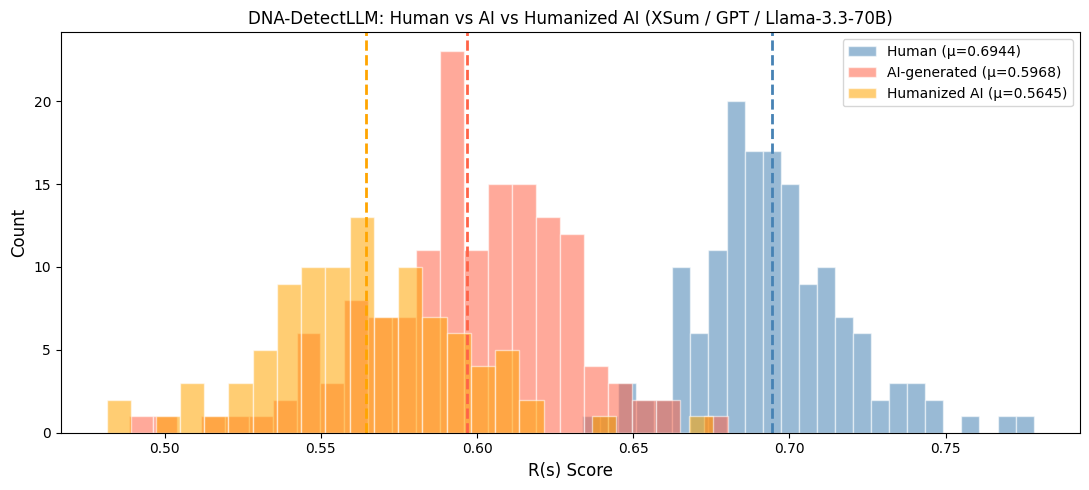

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(h_v,  bins=25, alpha=0.55, label=f'Human (μ={np.mean(h_v):.4f})',     color='steelblue',  edgecolor='white')
ax.hist(a_v,  bins=25, alpha=0.55, label=f'AI-generated (μ={np.mean(a_v):.4f})', color='tomato',  edgecolor='white')
ax.hist(hm_v, bins=25, alpha=0.55, label=f'Humanized AI (μ={np.mean(hm_v):.4f})', color='orange', edgecolor='white')
for val, col in [(np.mean(h_v),'steelblue'), (np.mean(a_v),'tomato'), (np.mean(hm_v),'orange')]:
    ax.axvline(val, color=col, ls='--', lw=2)
ax.set_xlabel('R(s) Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('DNA-DetectLLM: Human vs AI vs Humanized AI (XSum / GPT / Llama-3.3-70B)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('triplet_distributions.png', dpi=150)
plt.show()

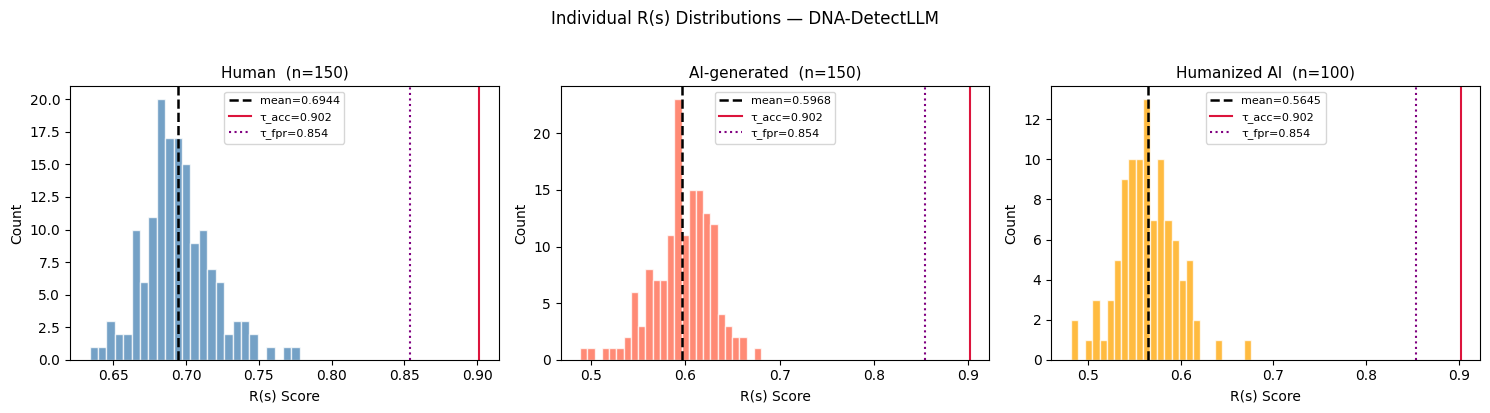

Paper thresholds: accuracy τ=0.9015, low-FPR τ=0.8536
Human     — above accuracy threshold: 0/150
AI        — below accuracy threshold: 150/150
Humanized — below accuracy threshold: 100/100


In [16]:
  # Individual distribution plots for each group
  THRESH_ACCURACY = 0.9015310749276843                                                                      
  THRESH_FPR      = 0.8536432310785527                      
                                                                                                            
  groups = [
      (h_v,  'Human',        'steelblue'),                                                                  
      (a_v,  'AI-generated', 'tomato'),                                                                     
      (hm_v, 'Humanized AI', 'orange'),
  ]                                                                                                         
                                                            
  fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)                                             
                                                            
  for ax, (vals, label, color) in zip(axes, groups):                                                        
      ax.hist(vals, bins=25, color=color, alpha=0.75, edgecolor='white')
      ax.axvline(np.mean(vals), color='black', ls='--', lw=1.8, label=f'mean={np.mean(vals):.4f}')          
      ax.axvline(THRESH_ACCURACY, color='crimson', ls='-', lw=1.5, label=f'τ_acc={THRESH_ACCURACY:.3f}')    
      ax.axvline(THRESH_FPR, color='purple', ls=':', lw=1.5, label=f'τ_fpr={THRESH_FPR:.3f}')               
      ax.set_title(f'{label}  (n={len(vals)})', fontsize=11)                                                
      ax.set_xlabel('R(s) Score', fontsize=10)                                                              
      ax.set_ylabel('Count', fontsize=10)                                                                   
      ax.legend(fontsize=8)                                                                                 
                                                                                                            
  plt.suptitle('Individual R(s) Distributions — DNA-DetectLLM', fontsize=12, y=1.02)                        
  plt.tight_layout()
  plt.savefig('triplet_individual_distributions.png', dpi=150, bbox_inches='tight')                         
  plt.show()                                                                                                
  
  print(f'Paper thresholds: accuracy τ={THRESH_ACCURACY:.4f}, low-FPR τ={THRESH_FPR:.4f}')                  
  print(f'Human     — above accuracy threshold: {sum(1 for v in h_v  if v > THRESH_ACCURACY)}/{len(h_v)}')
  print(f'AI        — below accuracy threshold: {sum(1 for v in a_v  if v < THRESH_ACCURACY)}/{len(a_v)}')  
  print(f'Humanized — below accuracy threshold: {sum(1 for v in hm_v if v < THRESH_ACCURACY)}/{len(hm_v)}')

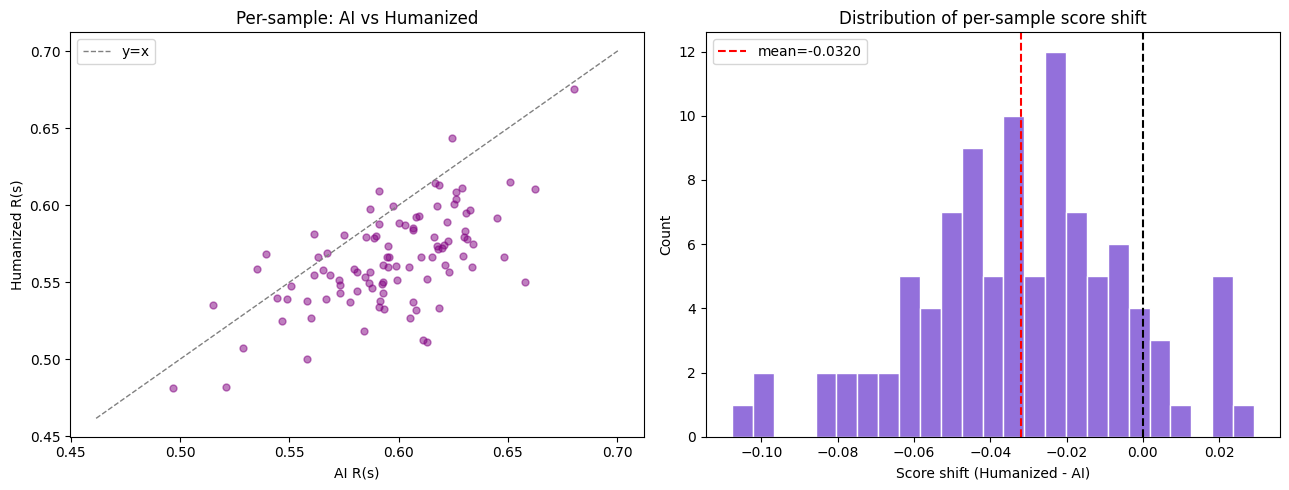

11/100 humanized texts scored HIGHER than their AI original


In [17]:
# per-triplet: how much does humanization move each sample?
triplet_valid = [(a, hm) for a, hm in zip(ai_scores, humanized_scores)
                 if not np.isnan(a) and not np.isnan(hm)]
ai_p  = [t[0] for t in triplet_valid]
hm_p  = [t[1] for t in triplet_valid]
shifts = [hm - a for a, hm in triplet_valid]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ai_p, hm_p, alpha=0.5, s=25, c='purple')
lims = [min(min(ai_p), min(hm_p))-0.02, max(max(ai_p), max(hm_p))+0.02]
axes[0].plot(lims, lims, '--', color='gray', lw=1, label='y=x')
axes[0].set_xlabel('AI R(s)')
axes[0].set_ylabel('Humanized R(s)')
axes[0].set_title('Per-sample: AI vs Humanized')
axes[0].legend()

axes[1].hist(shifts, bins=25, color='mediumpurple', edgecolor='white')
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].axvline(np.mean(shifts), color='red', ls='--', lw=1.5, label=f'mean={np.mean(shifts):+.4f}')
axes[1].set_xlabel('Score shift (Humanized - AI)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of per-sample score shift')
axes[1].legend()

plt.tight_layout()
plt.savefig('triplet_shift.png', dpi=150)
plt.show()

above = sum(1 for s in shifts if s > 0)
print(f"{above}/{len(shifts)} humanized texts scored HIGHER than their AI original")

In [18]:
output = {
    "dataset": "XSum (human) + GPT4_machine (AI) + Llama-3.3-70B humanization",
    "n": N,
    "human_mean": float(np.mean(h_v)),
    "human_std":  float(np.std(h_v)),
    "ai_mean":    float(np.mean(a_v)),
    "ai_std":     float(np.std(a_v)),
    "humanized_mean": float(np.mean(hm_v)),
    "humanized_std":  float(np.std(hm_v)),
    "human_ai_gap":       float(np.mean(h_v) - np.mean(a_v)),
    "humanized_ai_shift": float(np.mean(hm_v) - np.mean(a_v)),
    "gap_closed_pct":     float((np.mean(hm_v)-np.mean(a_v))/(np.mean(h_v)-np.mean(a_v))*100),
    "pct_humanized_higher": float(above/len(shifts)*100),
    "human_scores":     human_scores,
    "ai_scores":        ai_scores,
    "humanized_scores": humanized_scores,
}

with open("triplet_results.json", "w") as f:
    json.dump(output, f, indent=2)

summary = {k: v for k, v in output.items() if k not in ['human_scores','ai_scores','humanized_scores']}
print(json.dumps(summary, indent=2))

{
  "dataset": "XSum (human) + GPT4_machine (AI) + Llama-3.3-70B humanization",
  "n": 150,
  "human_mean": 0.6943720257282258,
  "human_std": 0.024149926553865452,
  "ai_mean": 0.5967805935939153,
  "ai_std": 0.032208743823244075,
  "humanized_mean": 0.5645460188388824,
  "humanized_std": 0.03135395528711571,
  "human_ai_gap": 0.09759143213431043,
  "humanized_ai_shift": -0.032234574755032885,
  "gap_closed_pct": -33.030127799200635,
  "pct_humanized_higher": 11.0
}
